In [130]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [131]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [132]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [133]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [134]:
################################################################################

In [135]:
#DATA DESCRIPTIONS

### Data Type
# MicroPulse Differential Absorption Lidar (MPD)

### DOI (Permanent Link)
# https://doi.org/10.26023/50Z5-ZHXE-7B0D

### Summary
# MicroPulse Differential Absorption Lidar (MPD) data 
# in NetCDF format which were collected during the 
# Prediction of Rainfall Extremes Campaign In the Pacific (PRECIP). 
# Three MPDs were deployed to Taiwan for this field project.

### Temporal Coverage
# Begin datetime 2022-05-28 00:00:00
# End datetime 2022-08-22 23:59:59

### Spatial Coverage
# Maximum (North) Latitude: 24.97, Minimum (South) Latitude: 24.76
# Minimum (West) Longitude: 121.01, Maximum (East) Longitude: 121.76

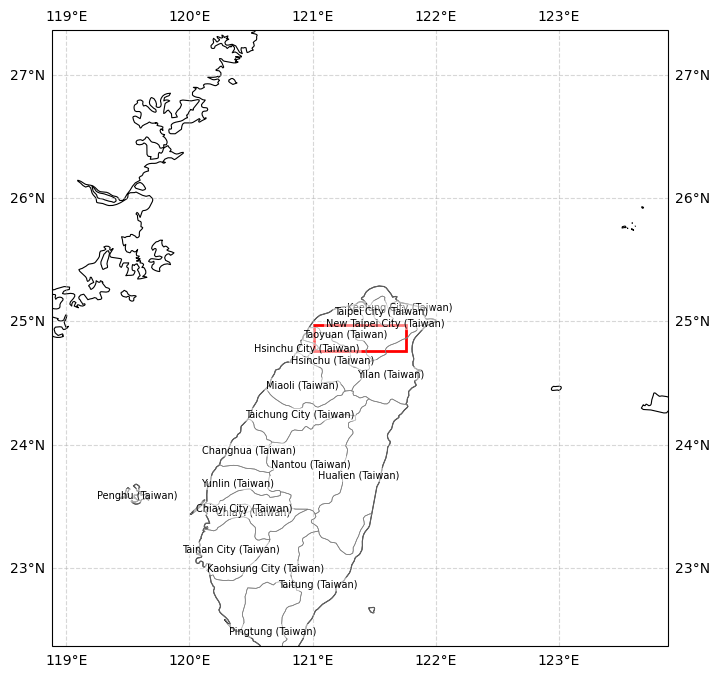

In [139]:
mapPlotting = MapPlotting(
    sw_corner=(24.76, 121.01),  # (lat_min, lon_min)
    ne_corner=(24.97, 121.76),  # (lat_max, lon_max)
    delta=2.5,
    fontsize=7
)
mapPlotting.PlotBoundingBox()

In [137]:
################################################################################

In [39]:
#SET UP DIRECTORIES
Campaign="PRECIP"
Date="20220527"
Downloaded_File="abrah3490212"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

#Data Directory
DataType="NCAR_SPol_RadarMoments_Data"
Observation_Data_Directory = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
Data_Directory1 = os.path.join(Observation_Data_Directory,Campaign,DataType,Downloaded_File,"unzip","sur",Date) #Surveillance scans
print("Data Directory Set as:", Data_Directory1, '\n')
FileList1 = ListFiles(Data_Directory1)

#Data Directory
DataType="NCAR_SPol_RadarMoments_Data"
Observation_Data_Directory = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
Data_Directory2 = os.path.join(Observation_Data_Directory,Campaign,DataType,Downloaded_File,"unzip","rhi",Date) #Range–Height Indicator scans
print("Data Directory Set as:", Data_Directory2, '\n')
FileList2 = ListFiles(Data_Directory2)

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP 

Data Directory Set as: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/NCAR_SPol_RadarMoments_Data/abrah3490212/unzip/sur/20220527 

Listing first 10 files:
 ['cfrad.20220527_152125.533_to_20220527_152343.923_SPOL_PrecipSur2_SUR.nc', 'cfrad.20220527_203646.127_to_20220527_204246.399_SPOL_PrecipSur1_SUR.nc', 'cfrad.20220527_222446.377_to_20220527_223045.449_SPOL_PrecipSur1_SUR.nc', 'cfrad.20220527_060046.155_to_20220527_060646.427_SPOL_PrecipSur1_SUR.nc', 'cfrad.20220527_130046.301_to_20220527_130646.715_SPOL_PrecipSur1_SUR.nc', 'cfrad.20220527_020925.587_to_20220527_021143.907_SPOL_PrecipSur2_SUR.nc', 'cfrad.20220527_053325.521_to_20220527_053544.053_SPOL_PrecipSur2_SUR.nc', 'cfrad.20220527_190046.315_to_20220527_190646.659_SPOL_PrecipSur1_SUR.nc', 'cfrad.20220527_232125.179_to_20220527_232343.499_SPOL_Precip

In [40]:
#READING DATA
###################################
# #how to unzip in terminal
# mkdir unzip
# for f in *.tar; do
#     tar -xvf "$f" -C unzip
# done

In [50]:
def GetData(index):
    DataFile = os.path.join(Data_Directory,FileList1[index])
    DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
    return DataNC

In [51]:
index=0
DataFile=os.path.join(Data_Directory,FileList1[index])
file_path=DataFile
if os.path.exists(file_path):
    print("File exists:", file_path)
else:
    print("File does not exist:", file_path)

File exists: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/NCAR_SPol_RadarMoments_Data/abrah3490212/unzip/sur/20220527/cfrad.20220527_152125.533_to_20220527_152343.923_SPOL_PrecipSur2_SUR.nc


In [178]:
#PLOTTING FUNCTIONS
###################################

In [123]:
#GETTING COLORMAPS

# The Python ARM Radar Toolkit - Py-ART
# git clone https://github.com/ProjectPythia/radar-cookbook.git
# pip install arm_pyart
import pyart

import inspect
print(inspect.getsource(pyart.config.get_field_colormap))
print(pyart.config._DEFAULT_FIELD_COLORMAP.keys())


cmap_reflectivity = pyart.config.get_field_colormap('reflectivity')
# cmap_dBZ = pyart.config.get_field_colormap('dBZ') #same as reflectivity
# cmap_dbz = pyart.config.get_field_colormap('dbz') #same as reflectivity
# cmap_DBZ = pyart.config.get_field_colormap('DBZ') #same as reflectivity
cmap_viridis = plt.cm.viridis
cmap_velocity = pyart.config.get_field_colormap('velocity')
cmap_inferno = plt.cm.inferno
# import matplotlib.cm as cm
# cmap = cm.get_cmap(cmap_reflectivity)
# cmap

def get_field_colormap(field):
    """
    Return the colormap name from the configuration file for a field name.
    """
    if field in _DEFAULT_FIELD_COLORMAP:
        return _DEFAULT_FIELD_COLORMAP[field]
    else:
        import matplotlib

        # Use the default matplotlib colormap
        return matplotlib.colormaps.get_cmap("Spectral_r").name

dict_keys(['reflectivity', 'corrected_reflectivity', 'total_power', 'signal_to_noise_ratio', 'velocity', 'corrected_velocity', 'simulated_velocity', 'eastward_wind_component', 'northward_wind_component', 'vertical_wind_component', 'spectrum_width', 'normalized_coherent_power', 'differential_reflectivity', 'corrected_differential_reflectivity', 'clutter_filter_power_removed', 'cross_correlation_ratio', 'logarithmic_cross_correlation_ratio', 'differential_phase', 'unfolded_differential_phase', 'corrected_differential_phase', 'specific_differential_phase', 'corrected_specific_differential_phase', 'linear_polarization_ratio', 'linear_depol

In [259]:
index=1
DataNC = GetData(index=index)
# DataNC.data_vars

radar_longitude=DataNC['longitude'].values
radar_latitude=DataNC['latitude'].values

nt = DataNC.sizes['time']    # 1920
nr = DataNC.sizes['range']   # 1999
times = DataNC['time']
ranges = DataNC['range']

# Example: Reflectivity
dbz = DataNC['DBZ'].values.reshape(nt, nr)   # (time, range)
vel = DataNC['VEL'].values.reshape(nt, nr)   # (time, range)

# Range (meters)
ranges = (DataNC['ray_start_range'][0].values +
          np.arange(nr) * DataNC['ray_gate_spacing'][0].values)

# Azimuth (degrees) – check if your dataset has "azimuth"
azimuths = DataNC['azimuth'].values   # (time,)

# Convert polar → Cartesian
r, theta = np.meshgrid(ranges, np.deg2rad(azimuths))
x = r * np.sin(theta)
y = r * np.cos(theta)

In [262]:
import numpy as np

R = 6.371e6  # Earth radius in m

# Convert offsets to degrees
dLat = (y / R) * (180 / np.pi)
dLon = (x / (R * np.cos(np.deg2rad(latitude)))) * (180 / np.pi)

# Absolute lat/lon
Latitude = radar_latitude + dLat
Longitude = radar_longitude + dLon

In [209]:
# #UNUSED FUNCTIONS

# def ConvertCoords(coord_tuple, units, ref_lat=0.0, R=6.371e6):
#     """
#     Convert between geographic (lon, lat in degrees) and Cartesian (x, y in meters).

#     Equations
#     ----------
#     dX = R * cos(ref_lat) * dλ
#     dY = R * dφ
#     where R = 6.371e6 m
#     """

#     if units in ['meters']:   # input = (x, y), output = (lon, lat) in degrees
#         dX = coord_tuple[0]
#         dY = coord_tuple[1]

#         dLongitude = dX / (R * np.cos(np.deg2rad(ref_lat)))
#         dLatitude  = dY / R

#         # convert back to degrees
#         dLongitude = np.rad2deg(dLongitude)
#         dLatitude  = np.rad2deg(dLatitude)

#         return dLongitude, dLatitude

#     elif units == 'degrees':  # input = (lon, lat), output = (x, y) in meters
#         dLongitude = np.deg2rad(coord_tuple[0])
#         dLatitude  = np.deg2rad(coord_tuple[1])

#         dX = R * np.cos(np.deg2rad(ref_lat)) * dLongitude
#         dY = R * dLatitude

#         return dX, dY

# dX=x.max()-x.min()
# dY=y.max()-y.min()
# coord_tuple=(dX,dY)
# (dLon, dLat) = ConvertCoords(coord_tuple=coord_tuple,units='meters',ref_lat=latitude)

In [289]:
#OLD PLOT TESTING
#################

# plt.contourf(x/1000, y/1000, dbz, cmap=cmap_reflectivity)
# plt.colorbar(label="Reflectivity (dBZ)")
# plt.xlabel("East-West distance (km)")
# plt.ylabel("North-South distance (km)")
# plt.axis("equal")
# plt.show()

# plt.contourf(x/1000, y/1000, vel, cmap=cmap_velocity)
# plt.colorbar(label="Radial Velocity (m/s)")
# plt.xlabel("East-West distance (km)")
# plt.ylabel("North-South distance (km)")
# plt.axis("equal")
# plt.show()

# plt.contourf(Longitude,Latitude,dbz, cmap=cmap_velocity)
# plt.colorbar(label="Reflectivity (dBZ)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.axis("equal")
# plt.show()

# plt.contourf(Longitude,Latitude,vel, cmap=cmap_velocity)
# plt.colorbar(label="Radial Velocity (m/s)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.axis("equal")
# plt.show()

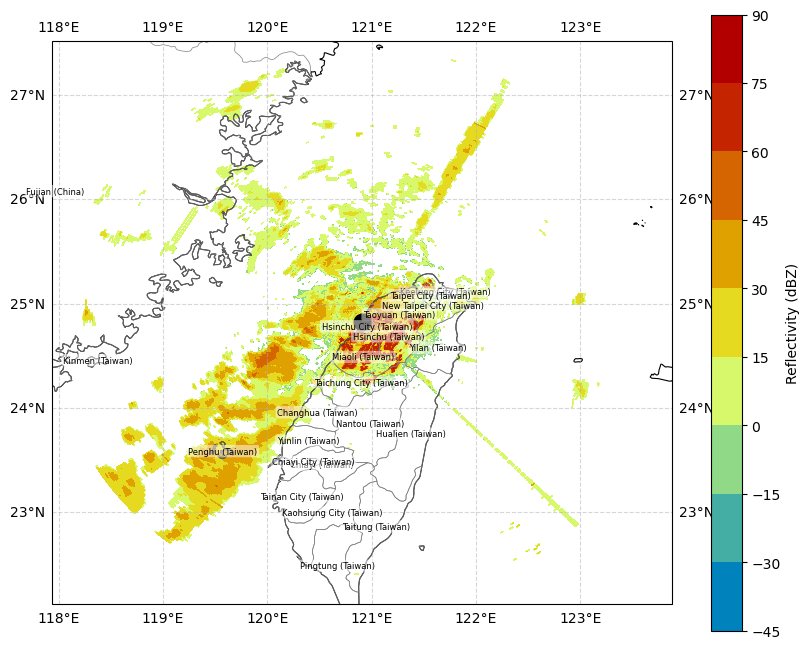

In [292]:
# Create normal matplotlib Axes (not cartopy GeoAxes)
plotter = MapPlotting(fontsize=6)

# Plot map from lon/lat bounds
fig, ax = plotter.PlotFromBounds(lat_min=Latitude.min(), lat_max=Latitude.max(),
                                 lon_min=Longitude.min(), lon_max=Longitude.max())


# Plot your radar data
cs = ax.contourf(Longitude, Latitude, dbz, cmap=cmap_reflectivity,transform=ccrs.PlateCarree())
plt.colorbar(cs, ax=ax, label="Reflectivity (dBZ)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

# Plot Radar Location Point
ax.plot(radar_longitude, radar_latitude, "o", color="black", markersize=12)

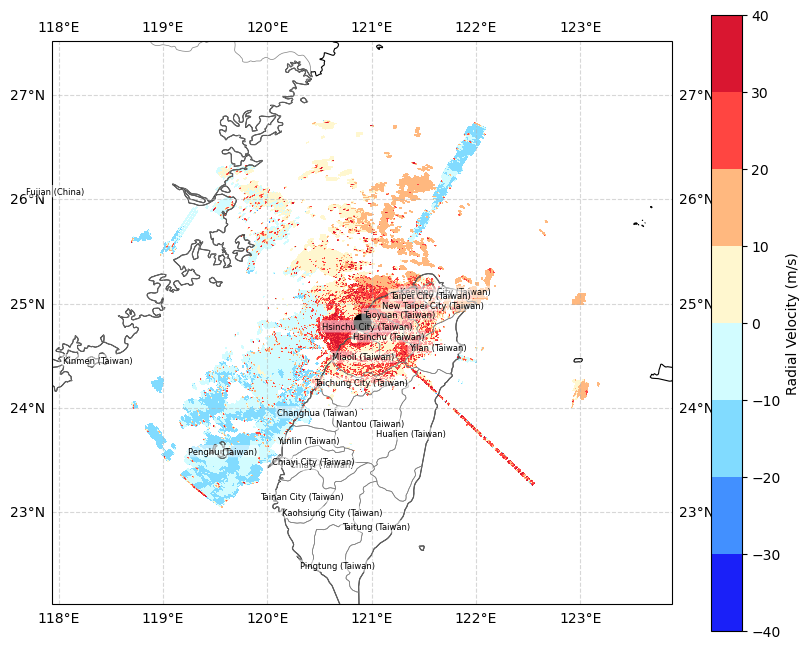

In [293]:
# Create normal matplotlib Axes (not cartopy GeoAxes)
plotter = MapPlotting(fontsize=6)

# Plot map from lon/lat bounds
fig, ax = plotter.PlotFromBounds(lat_min=Latitude.min(), lat_max=Latitude.max(),
                                 lon_min=Longitude.min(), lon_max=Longitude.max())


# Plot your radar data
cs = ax.contourf(Longitude, Latitude, vel, cmap=cmap_velocity,transform=ccrs.PlateCarree())
plt.colorbar(cs, ax=ax, label="Radial Velocity (m/s)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

# Plot Radar Location Point
ax.plot(radar_longitude, radar_latitude, "o", color="black", markersize=12)